In [77]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import math
import Bio
DF_A = pd.read_csv("A_vs_E.deseq2.results.tsv", sep = '\t')

regulation = [
    (DF_A['log2FoldChange'] > 0) & (DF_A['padj'] < 0.05),
    (DF_A['log2FoldChange'] < 0) & (DF_A['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(regulation, choices, default='NotSign')
print(DF_A)

DF_A = DF_A.dropna()


      gene_id      baseMean  log2FoldChange     lfcSE         pvalue  \
0       Q0020   2846.323000       -0.674463  0.417231   6.399530e-02   
1       Q0045   4965.675000        2.296439  1.239693   3.565016e-04   
2       Q0050  97393.600000       -1.486858  0.272632   6.002426e-09   
3       Q0055   9176.751000      -11.521390  0.365692  3.845847e-219   
4       Q0060   1104.390000       -0.297461  0.284158   2.665799e-01   
...       ...           ...             ...       ...            ...   
6392  YPR200C     11.660700       -1.479523  0.650821   1.709386e-03   
6393  YPR201W      6.547552       -0.199252  0.530156   6.351699e-01   
6394  YPR202W      1.681190       -0.323915  0.863129   4.037290e-01   
6395  YPR203W      0.983849        0.025143  0.928803   9.337711e-01   
6396  YPR204W      1.467066       -0.080458  1.082443   6.131790e-01   

               padj Up/Down_Reg  
0      1.190438e-01     NotSign  
1      1.379378e-03          Up  
2      8.074787e-08        Down  

In [2]:
DF_A1v = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
DF_A1v


,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
4785,YNCI0010C,46.89281,22.73216,4.071234,7.591811e-09,9.949354e-08,Up
4812,YNCJ0024W,190.41880,22.69953,3.870816,1.676109e-09,2.559952e-08,Up
4807,YNCJ0019C,76.98781,21.33574,3.263297,2.798018e-11,6.558124e-10,Up
4966,YNCP0007C,27.80624,18.94057,7.824438,9.391192e-06,5.567113e-05,Up
4671,YNCD0031C,24.41078,14.98176,10.070923,4.151034e-05,2.065012e-04,Up
...,...,...,...,...,...,...,...
4647,YNCD0006W,234.41260,-22.89752,2.750485,3.681924e-17,2.609028e-15,Down
4803,YNCJ0015W,136.51010,-23.92417,3.881110,2.637350e-10,4.855593e-09,Down
4898,YNCM0024W,86.56634,-24.01399,2.878474,2.917983e-17,2.116927e-15,Down
4832,YNCK0014W,140.30120,-24.72490,3.992780,2.094598e-10,3.976473e-09,Down


In [3]:
DF_A1v = DF_A1v.rename(columns={'log2FoldChange': 'log2fc_A'})
DF_A1v = DF_A1v.head(15)

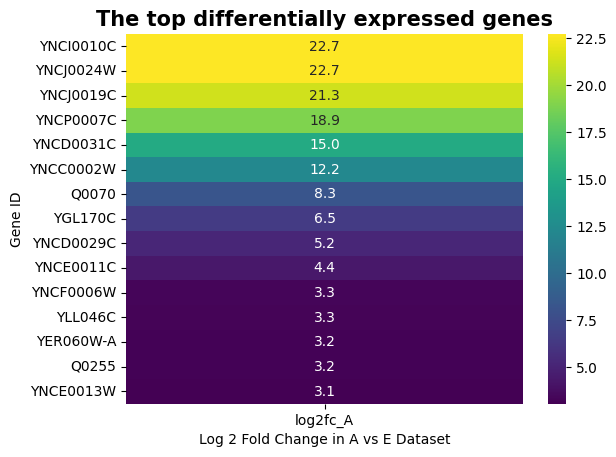

In [4]:
sns.heatmap(DF_A1v[['log2fc_A']].set_index(DF_A1v['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top differentially expressed genes", fontsize = 15, weight = "bold")
plt.ylabel("Gene ID", fontsize = 10)
plt.xlabel("Log 2 Fold Change in A vs E Dataset")
plt.show()

      gene_id      baseMean  log2FoldChange     lfcSE        pvalue  \
0       Q0020   2846.323000       -2.302744  0.456351  2.566579e-08   
1       Q0045   4965.675000       -0.976205  0.873683  1.063241e-01   
2       Q0050  97393.600000       -2.984874  0.280593  7.808072e-29   
3       Q0055   9176.751000       -1.730134  0.378653  1.210130e-06   
4       Q0060   1104.390000       -1.085074  0.292156  1.203540e-04   
...       ...           ...             ...       ...           ...   
6392  YPR200C     11.660700       -1.657078  0.639239  1.914163e-03   
6393  YPR201W      6.547552       -0.893711  0.549416  6.413410e-02   
6394  YPR202W      1.681190       -0.731186  1.041286  2.028178e-01   
6395  YPR203W      0.983849        0.181616  1.145710  6.916343e-01   
6396  YPR204W      1.467066        0.000000  1.294563  1.000000e+00   

              padj  
0     1.602344e-07  
1     1.681830e-01  
2     1.500806e-26  
3     5.606908e-06  
4     3.849750e-04  
...            ...  


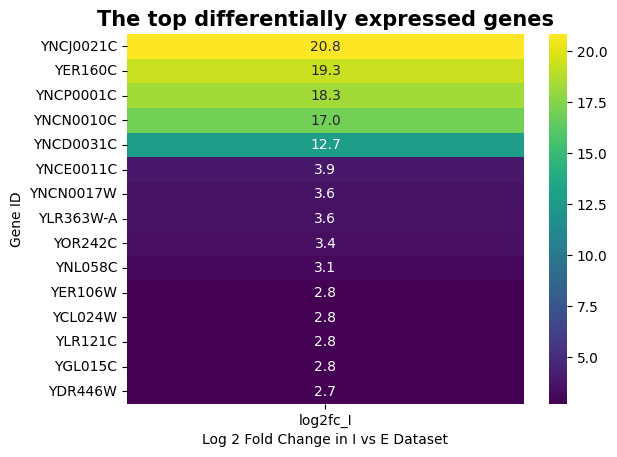

In [5]:
DF_I = pd.read_csv("I_vs_E.deseq2.results.tsv", sep = '\t')

regulation = [
    (DF_I['log2FoldChange'] > 0) & (DF_I['padj'] < 0.05),
    (DF_I['log2FoldChange'] < 0) & (DF_I['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(regulation, choices, default='NotSign')
print(DF_I)

DF_I1v = DF_I.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
DF_I1v = DF_I1v.rename(columns={'log2FoldChange': 'log2fc_I'})
DF_I1v = DF_I1v.head(15)
sns.heatmap(DF_I1v[['log2fc_I']].set_index(DF_I1v['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top differentially expressed genes", fontsize = 15, weight = "bold")
plt.ylabel("Gene ID", fontsize = 10)
plt.xlabel("Log 2 Fold Change in I vs E Dataset")
plt.show()

In [29]:
DF_A

,gene_id,baseMean,log2FoldChange,lfcSE,pvalue,padj,Up/Down_Reg
0,Q0020,2846.323000,-0.674463,0.417231,6.399530e-02,1.190438e-01,Down
1,Q0045,4965.675000,2.296439,1.239693,3.565016e-04,1.379378e-03,NotSign
2,Q0050,97393.600000,-1.486858,0.272632,6.002426e-09,8.074787e-08,Down
3,Q0055,9176.751000,-11.521390,0.365692,3.845847e-219,2.343659e-215,Down
4,Q0060,1104.390000,-0.297461,0.284158,2.665799e-01,3.822442e-01,Down
...,...,...,...,...,...,...,...
6392,YPR200C,11.660700,-1.479523,0.650821,1.709386e-03,5.344792e-03,Down
6393,YPR201W,6.547552,-0.199252,0.530156,6.351699e-01,7.355996e-01,NotSign
6394,YPR202W,1.681190,-0.323915,0.863129,4.037290e-01,5.250373e-01,NotSign
6395,YPR203W,0.983849,0.025143,0.928803,9.337711e-01,NaN,NotSign


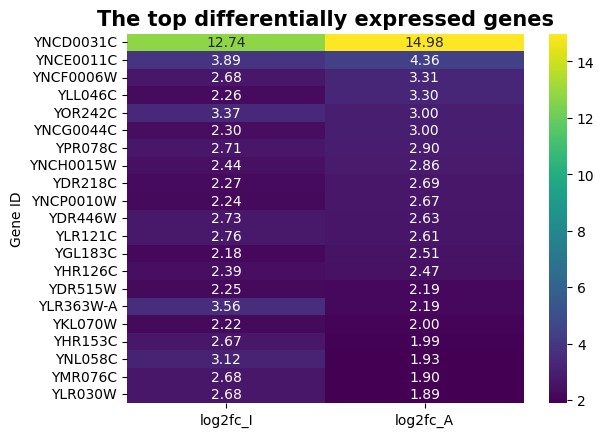

In [25]:
#HEATMAP 3-Top Differentialy Expressed Common Genes across the Conditions
DFA3v = DF_A.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
DFA3v = DFA3v.head(100)

DFI3v = DF_I.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
DFI3v = DFI3v.head(100)

DFA3v = DFA3v.rename(columns={'log2FoldChange': 'log2fc_A'})
DFI3v = DFI3v.rename(columns={'log2FoldChange': 'log2fc_I'})

MERGED4v = DFA3v.merge(DFI3v, on = 'gene_id')
sns.heatmap(MERGED4v[['log2fc_I', 'log2fc_A']].set_index(MERGED4v['gene_id']), annot = True, fmt=".2f", cmap= 'viridis')
plt.title("The top differentially expressed genes", fontsize = 15, weight = "bold")
plt.ylabel("Gene ID", fontsize = 10)
plt.show()

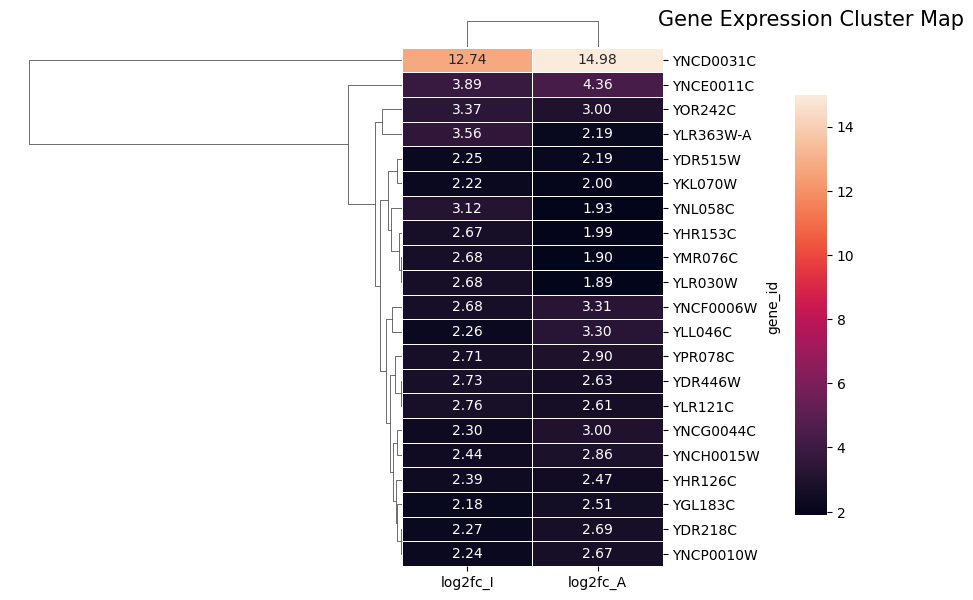

In [78]:
#Additional Analyses-This is a Clustered Heatmap
sns.clustermap(MERGED4v[['log2fc_I', 'log2fc_A']].set_index(MERGED4v['gene_id']), 
           annot=True, figsize=(8,6), dendrogram_ratio=(.6, .05), cbar_pos=(1, .15, .04, .7), linewidths=0.55, fmt=".2f")
plt.title("Gene Expression Cluster Map", fontsize=15, pad =50)
plt.show()

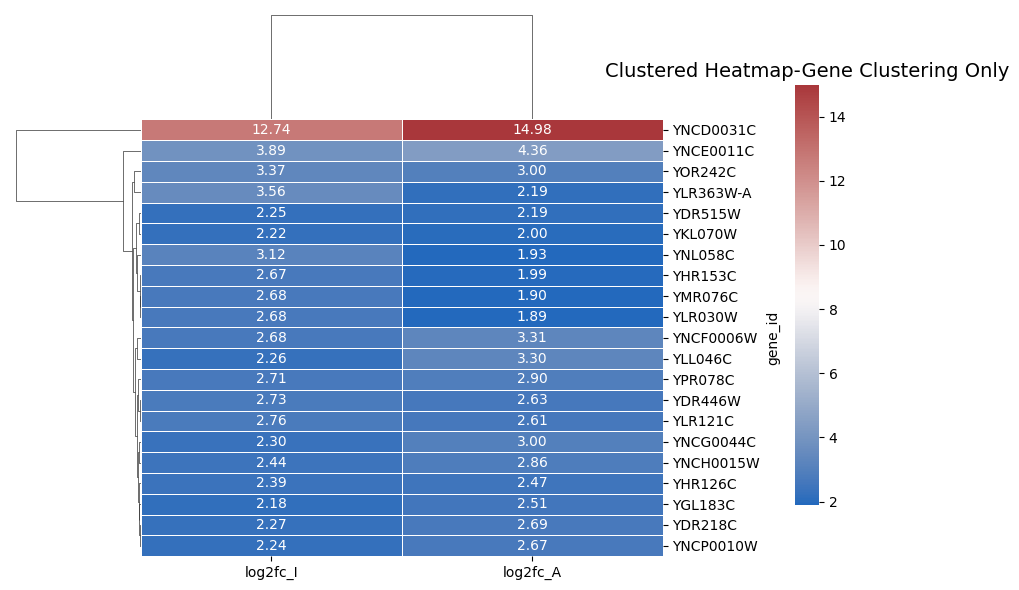

In [74]:
sns.clustermap(
    MERGED4v[['log2fc_I', 'log2fc_A']].set_index(MERGED4v['gene_id']),
    annot=True, fmt=".2f", cmap="vlag",
    figsize=(8, 6), linewidths=0.5, cbar_pos=(1, .15, .03, .7))
plt.title("Clustered Heatmap-Gene Clustering Only", fontsize=14)
plt.show()

      gene_id      baseMean  log2FoldChange     lfcSE        pvalue  \
0       Q0020   2846.323000       -2.302744  0.456351  2.566579e-08   
1       Q0045   4965.675000       -0.976205  0.873683  1.063241e-01   
2       Q0050  97393.600000       -2.984874  0.280593  7.808072e-29   
3       Q0055   9176.751000       -1.730134  0.378653  1.210130e-06   
4       Q0060   1104.390000       -1.085074  0.292156  1.203540e-04   
...       ...           ...             ...       ...           ...   
6392  YPR200C     11.660700       -1.657078  0.639239  1.914163e-03   
6393  YPR201W      6.547552       -0.893711  0.549416  6.413410e-02   
6394  YPR202W      1.681190       -0.731186  1.041286  2.028178e-01   
6395  YPR203W      0.983849        0.181616  1.145710  6.916343e-01   
6396  YPR204W      1.467066        0.000000  1.294563  1.000000e+00   

              padj  
0     1.602344e-07  
1     1.681830e-01  
2     1.500806e-26  
3     5.606908e-06  
4     3.849750e-04  
...            ...  


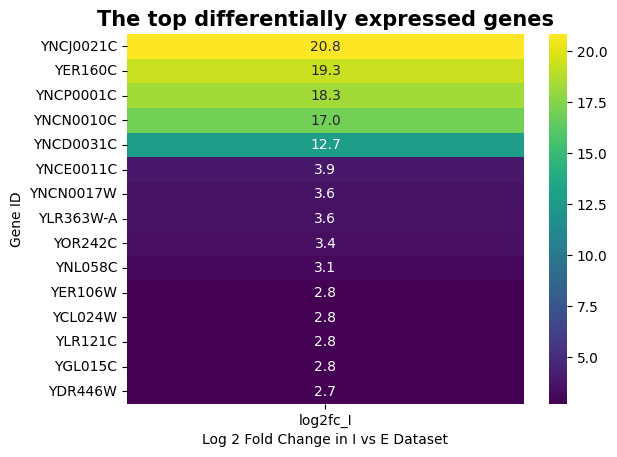

In [75]:


#HEATMAP 2-Top Differentialy Expressed Genes in I vs E Deseq2 Results
DF_I = pd.read_csv("I_vs_E.deseq2.results.tsv", sep = '\t')

regulation = [
    (DF_I['log2FoldChange'] > 0) & (DF_I['padj'] < 0.05),
    (DF_I['log2FoldChange'] < 0) & (DF_I['padj'] < 0.05)]
choices = ['Up', 'Down']

DF_A['Up/Down_Reg'] = np.select(regulation, choices, default='NotSign')
print(DF_I)

DF_I1v = DF_I.sort_values(by=["log2FoldChange", "padj"],
                             ascending=[False, True])
DF_I1v = DF_I1v.rename(columns={'log2FoldChange': 'log2fc_I'})
DF_I1v = DF_I1v.head(15)
sns.heatmap(DF_I1v[['log2fc_I']].set_index(DF_I1v['gene_id']), annot = True, fmt=".1f", cmap= 'viridis')
plt.title("The top differentially expressed genes", fontsize = 15, weight = "bold")
plt.ylabel("Gene ID", fontsize = 10)
plt.xlabel("Log 2 Fold Change in I vs E Dataset")
plt.show()

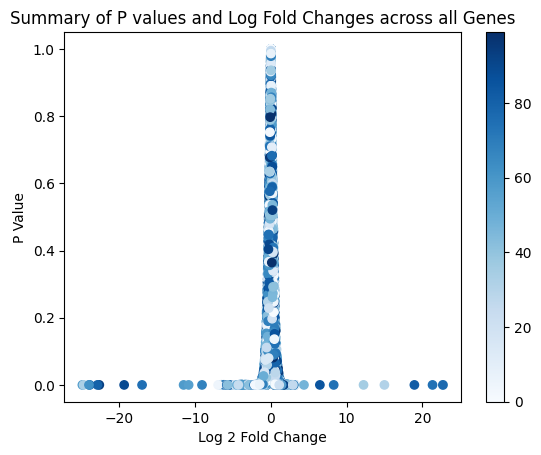

In [79]:
#Summary of p-values and log fold changes across all genes for each comparison.
x = (DF_A['log2FoldChange'])
y = (DF_A['pvalue'])
colors = np.random.randint(100, size = len(DF_A))
plt.scatter(x, y, c = colors, cmap = 'Blues')
plt.colorbar()
plt.xlabel("Log 2 Fold Change", fontsize=10)
plt.ylabel("P Value", fontsize=10)
plt.title("Summary of P values and Log Fold Changes across all Genes")
plt.show()


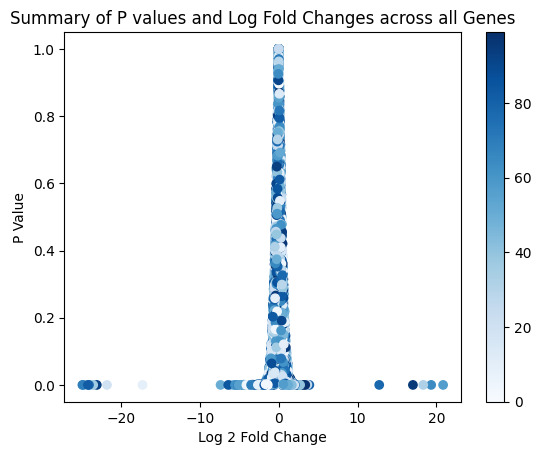

In [80]:
#Summary of p-values and log fold changes across all genes for each comparison.
x = (DF_I['log2FoldChange'])
y = (DF_I['pvalue'])
colors = np.random.randint(100, size = len(DF_I))
plt.scatter(x, y, c = colors, cmap = 'Blues')
plt.colorbar()
plt.xlabel("Log 2 Fold Change", fontsize=10)
plt.ylabel("P Value", fontsize=10)
plt.title("Summary of P values and Log Fold Changes across all Genes")
plt.show()


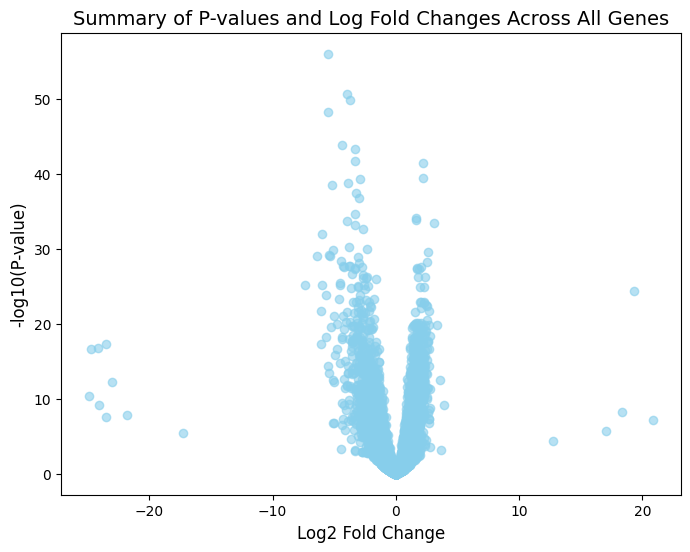

In [81]:
import matplotlib.pyplot as plt
import numpy as np

x = DF_I['log2FoldChange']
y = -np.log10(DF_I['pvalue'])  # makes low p-values appear higher

plt.figure(figsize=(8,6))
plt.scatter(x, y, c='skyblue', alpha=0.6)  # all points same color
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-log10(P-value)", fontsize=12)
plt.title("Summary of P-values and Log Fold Changes Across All Genes", fontsize=14)
plt.show()

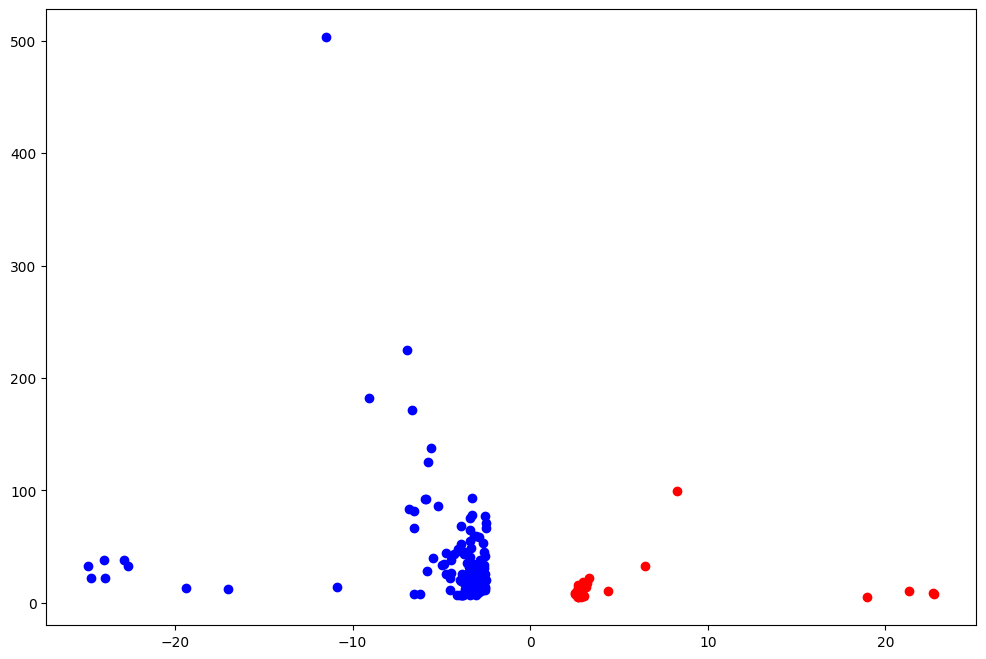

In [83]:
##Calculate log10 Value
DF_A['NegLog_Pval'] = -np.log10(DF_A['pvalue'])
plt.figure(figsize = (12,8))

##Scatter plot of Upregulated Genes
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] >= 2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_A['NegLog_Pval'] = -np.log(DF_A['pvalue'])
plt.scatter(DF_A['log2FoldChange'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
            DF_A['NegLog_Pval'][(DF_A['padj'] < 0.05) & (DF_A['log2FoldChange'] <= -2.5) & (DF_A['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')

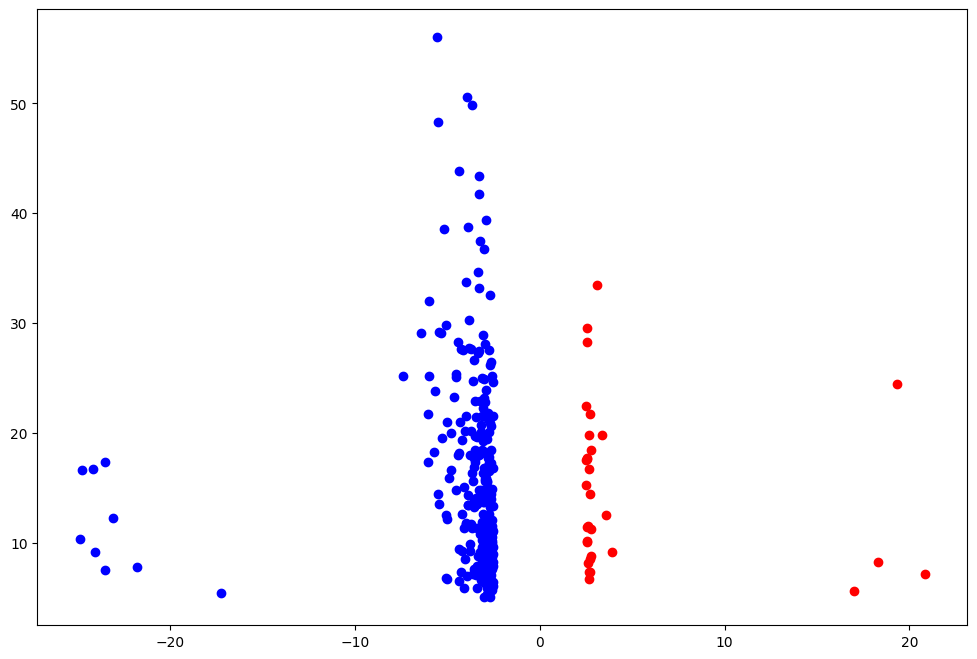

In [111]:
##Calculate log10 Value
DF_I['NegLog_Pval'] = -np.log10(DF_I['pvalue'])
plt.figure(figsize = (12,8))

##Scatter plot of Upregulated Genes
plt.scatter(DF_I['log2FoldChange'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] >= 2.5) & (DF_I['NegLog_Pval'] >= 5)],
            DF_I['NegLog_Pval'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] >= 2.5) & (DF_I['NegLog_Pval'] >= 5)],
c = 'red', label = 'Upregulated')
##Scatter Plot of Downregulated Genes
DF_I['NegLog_Pval'] = -np.log10(DF_I['pvalue'])
plt.scatter(DF_I['log2FoldChange'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] <= -2.5) & (DF_I['NegLog_Pval'] >= 5)],
            DF_I['NegLog_Pval'][(DF_I['padj'] < 0.05) & (DF_I['log2FoldChange'] <= -2.5) & (DF_I['NegLog_Pval'] >= 5)],
c = 'blue', label = 'Downregulated')

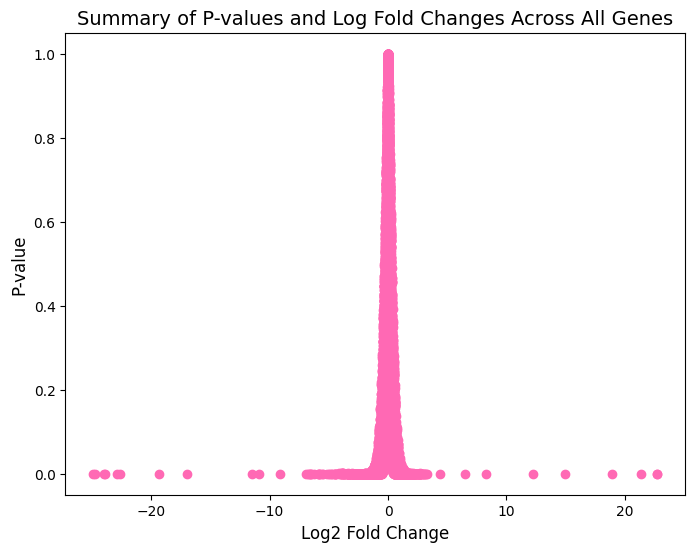

In [103]:
plt.figure(figsize=(8,6))
plt.scatter(DF_A[['log2FoldChange']], DF_A[['pvalue']], color = 'hotpink') 
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("P-value", fontsize=12)
plt.title("Summary of P-values and Log Fold Changes Across All Genes", fontsize=14)
plt.show()

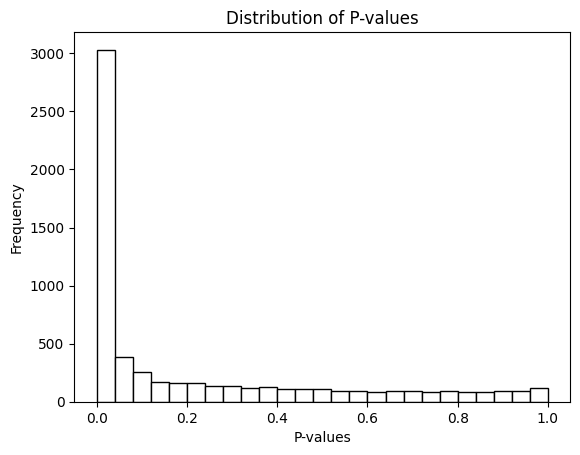

In [108]:
#DF_A - Histogram of P-value Distribution
plt.hist(DF_A['pvalue'], bins = 25, color = 'white', edgecolor = 'black')
plt.title("Distribution of P-values")
plt.xlabel("P-values")
plt.ylabel("Frequency")
plt.show()

In [109]:
#DF_A - Basic Summary of P-values and Log Fold Changes
DF_A[['log2FoldChange', 'pvalue']].describe()

,log2FoldChange,pvalue
count,6094.000000,6.094000e+03
mean,-0.131371,2.133912e-01
std,1.443180,2.942642e-01
min,-24.882900,3.845847e-219
25%,-0.628644,2.863758e-04
50%,-0.032872,4.142155e-02
75%,0.510509,3.667528e-01
max,22.732160,1.000000e+00


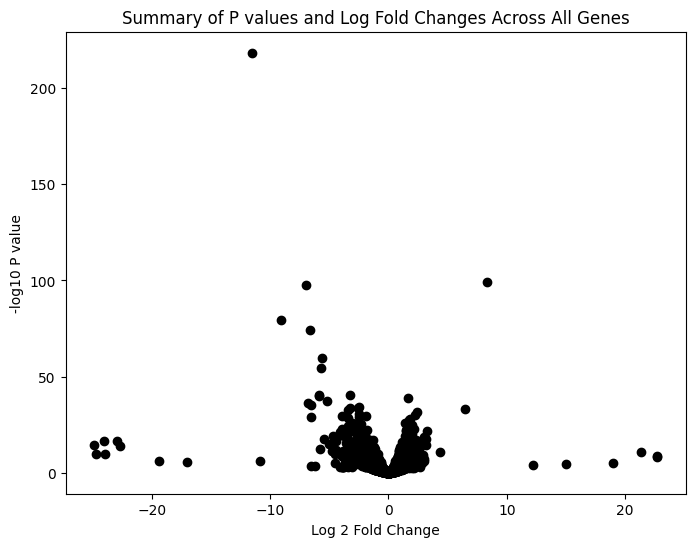

In [131]:
#Summary of p-values and log fold changes across all genes for each comparison-This plot has -log10 the P-Values for better spread/visuals
x = DF_A['log2FoldChange'] 
y = -np.log10(DF_A['pvalue'])  
plt.figure(figsize=(8,6)) 
plt.scatter(x, y, color = 'black') 
plt.xlabel("Log 2 Fold Change", fontsize=10) 
plt.ylabel("-log10 P value", fontsize=10) 
plt.title("Summary of P values and Log Fold Changes Across All Genes") 
plt.show()

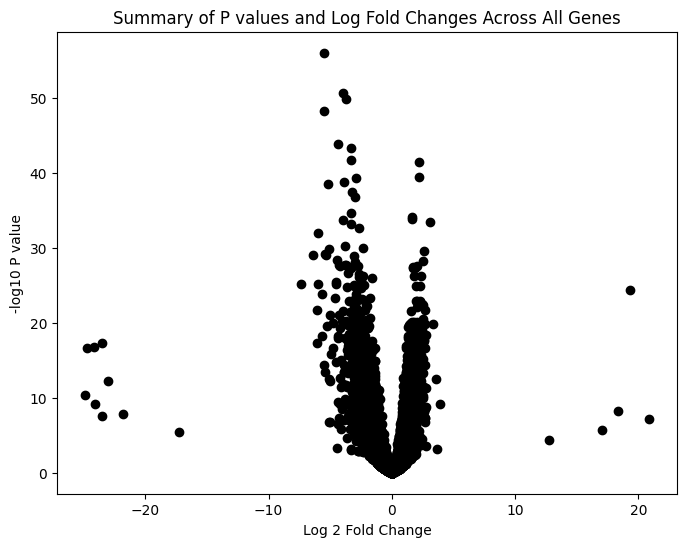

In [132]:
x = DF_I['log2FoldChange'] 
y = -np.log10(DF_I['pvalue'])  
plt.figure(figsize=(8,6)) 
plt.scatter(x, y, color = 'black') 
plt.xlabel("Log 2 Fold Change", fontsize=10) 
plt.ylabel("-log10 P value", fontsize=10) 
plt.title("Summary of P values and Log Fold Changes Across All Genes") 
plt.show()